# Weekend NetCDF QC Triage

Run this notebook from top to bottom to build QC plots from `outputs/weekend_nc`, start the AURORA QC triage server, and open the HTML triage UI inside the notebook.

In [1]:
from __future__ import annotations

import subprocess
import sys
import threading
import time
import webbrowser
from pathlib import Path
from urllib.request import urlopen

from IPython.display import HTML, IFrame, display
import matplotlib.pyplot as plt

REPO_ROOT = Path.cwd()
GRID_ROOT = REPO_ROOT / "roadrunner_egp" / "aurora_subneptune_grid"
SRC_ROOT = GRID_ROOT / "src"
ROADRUNNER_ROOT = GRID_ROOT.parent

for extra_path in (SRC_ROOT, ROADRUNNER_ROOT):
    if str(extra_path) not in sys.path:
        sys.path.insert(0, str(extra_path))

NC_DIR = REPO_ROOT / "outputs" / "weekend_nc"
QC_ROOT = REPO_ROOT / "outputs" / "weekend_nc_qc"
REPORT_ROOT = QC_ROOT / "reports"
PLOT_ROOT = QC_ROOT / "plots"
DECISIONS_CSV = QC_ROOT / "triage_decisions.csv"
QC_SUMMARY_CSV = REPORT_ROOT / "qc_summary.csv"
QC_SUMMARY_JSON = REPORT_ROOT / "qc_summary.json"
QC_FLAGS_CSV = REPORT_ROOT / "qc_flags.csv"

print(f"Repo root: {REPO_ROOT}")
print(f"NetCDF input: {NC_DIR}")
print(f"QC reports: {REPORT_ROOT}")
print(f"QC plots: {PLOT_ROOT}")

Repo root: /home/u11/danielxinhuang/Documents/aurora
NetCDF input: /home/u11/danielxinhuang/Documents/aurora/outputs/weekend_nc
QC reports: /home/u11/danielxinhuang/Documents/aurora/outputs/weekend_nc_qc/reports
QC plots: /home/u11/danielxinhuang/Documents/aurora/outputs/weekend_nc_qc/plots


In [2]:
nc_files = sorted(path for path in NC_DIR.glob("*.nc") if not path.name.endswith(".tmp.nc"))
if not nc_files:
    raise FileNotFoundError(f"No NetCDF files found in {NC_DIR}")

print(f"Found {len(nc_files)} NetCDF files")
print(nc_files[0])

Found 1384 NetCDF files
/home/u11/danielxinhuang/Documents/aurora/outputs/weekend_nc/run_0000000.nc


## Build QC Reports And Plots

`PLOT_ALL = False` only creates plots for warning/failing/rerun-recommended models. Set it to `True` if you want every weekend NetCDF to appear in the triage HTML.

In [3]:
PLOT_ALL = False

REPORT_ROOT.mkdir(parents=True, exist_ok=True)
PLOT_ROOT.mkdir(parents=True, exist_ok=True)

command = [
    sys.executable,
    str(GRID_ROOT / "scripts" / "validate_grid_outputs.py"),
    "--output-root",
    str(NC_DIR),
    "--out-csv",
    str(QC_SUMMARY_CSV),
    "--out-json",
    str(QC_SUMMARY_JSON),
    "--out-flags",
    str(QC_FLAGS_CSV),
    "--plot-root",
    str(PLOT_ROOT),
    "--make-plots",
]
if PLOT_ALL:
    command.append("--plot-all")

print("Running:")
print(" ".join(command))
completed = subprocess.run(command, cwd=REPO_ROOT, text=True, capture_output=True)
print(completed.stdout)
if completed.stderr:
    print(completed.stderr)
print(f"Exit code: {completed.returncode}")

print(f"QC summary: {QC_SUMMARY_CSV}")
print(f"QC flags: {QC_FLAGS_CSV}")
print(f"Plot root: {PLOT_ROOT}")

Running:
/home/u11/danielxinhuang/.local/share/mamba/envs/picaso4/bin/python /home/u11/danielxinhuang/Documents/aurora/roadrunner_egp/aurora_subneptune_grid/scripts/validate_grid_outputs.py --output-root /home/u11/danielxinhuang/Documents/aurora/outputs/weekend_nc --out-csv /home/u11/danielxinhuang/Documents/aurora/outputs/weekend_nc_qc/reports/qc_summary.csv --out-json /home/u11/danielxinhuang/Documents/aurora/outputs/weekend_nc_qc/reports/qc_summary.json --out-flags /home/u11/danielxinhuang/Documents/aurora/outputs/weekend_nc_qc/reports/qc_flags.csv --plot-root /home/u11/danielxinhuang/Documents/aurora/outputs/weekend_nc_qc/plots --make-plots
validated_files: 1384
failed: 12
warnings: 18
qc_summary_csv: /home/u11/danielxinhuang/Documents/aurora/outputs/weekend_nc_qc/reports/qc_summary.csv
qc_summary_json: /home/u11/danielxinhuang/Documents/aurora/outputs/weekend_nc_qc/reports/qc_summary.json
qc_flags_csv: /home/u11/danielxinhuang/Documents/aurora/outputs/weekend_nc_qc/reports/qc_flag

## QC CSVs And Pass/Fail Stats

QC summary CSV: /home/u11/danielxinhuang/Documents/aurora/outputs/weekend_nc_qc/reports/qc_summary.csv
QC flags CSV: /home/u11/danielxinhuang/Documents/aurora/outputs/weekend_nc_qc/reports/qc_flags.csv


,metric,count
0,total_files,1384
1,passed,1354
2,warnings,18
3,failed_or_rerun,12
4,rerun_recommended,12


,status,count
0,pass,1354
1,warning,18
2,rerun_recommended,12


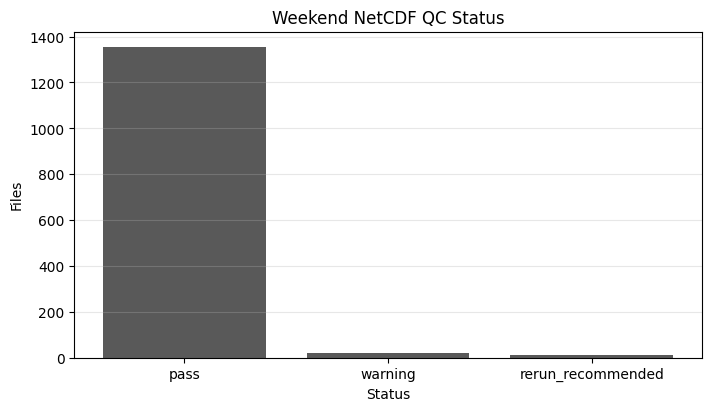

,run_index,run_id,file_path,status,storage_level,severity,fail_reasons,warning_reasons,rerun_recommended,has_wavelength,...,wavelength_max,pressure_min,pressure_max,temperature_min,temperature_max,max_adiabat_ratio,n_adiabat_violations,max_abs_fnet_irfnet,max_brightness_temperature,bottom_temperature
0,0,25169bb23781,/home/u11/danielxinhuang/Documents/aurora/outp...,pass,aurora_schema_v1,pass,NaN,NaN,False,True,...,2.5,0.000001,31.622777,232.757281,1411.068316,1.007063,0,1.788522,1089.063444,1411.068316
1,1,aeed9814dd9b,/home/u11/danielxinhuang/Documents/aurora/outp...,pass,aurora_schema_v1,pass,NaN,NaN,False,True,...,2.5,0.000001,31.622777,232.757281,1411.068316,1.007063,0,1.788522,1089.063444,1411.068316
2,2,6353fcd4ce64,/home/u11/danielxinhuang/Documents/aurora/outp...,pass,aurora_schema_v1,pass,NaN,NaN,False,True,...,2.5,0.000001,31.622777,232.757281,1411.068316,1.007063,0,1.788522,1089.063444,1411.068316
3,3,81d0478322ba,/home/u11/danielxinhuang/Documents/aurora/outp...,pass,aurora_schema_v1,pass,NaN,NaN,False,True,...,2.5,0.000001,31.622777,276.805666,1754.812151,1.008604,0,0.896001,1275.080738,1754.812151
4,4,8123056094a4,/home/u11/danielxinhuang/Documents/aurora/outp...,pass,aurora_schema_v1,pass,NaN,NaN,False,True,...,2.5,0.000001,31.622777,276.805666,1754.812151,1.008604,0,0.896001,1275.080738,1754.812151
5,5,d459f5940c14,/home/u11/danielxinhuang/Documents/aurora/outp...,pass,aurora_schema_v1,pass,NaN,NaN,False,True,...,2.5,0.000001,31.622777,276.805666,1754.812151,1.008604,0,0.896001,1275.080738,1754.812151
6,6,5e6c2eafda4c,/home/u11/danielxinhuang/Documents/aurora/outp...,pass,aurora_schema_v1,pass,NaN,NaN,False,True,...,2.5,0.000001,31.622777,232.757281,1411.068316,1.007063,0,1.788522,1089.063444,1411.068316
7,7,cde0311e4423,/home/u11/danielxinhuang/Documents/aurora/outp...,pass,aurora_schema_v1,pass,NaN,NaN,False,True,...,2.5,0.000001,31.622777,232.757281,1411.068316,1.007063,0,1.788522,1089.063444,1411.068316
8,8,967757f0ab88,/home/u11/danielxinhuang/Documents/aurora/outp...,pass,aurora_schema_v1,pass,NaN,NaN,False,True,...,2.5,0.000001,31.622777,232.757281,1411.068316,1.007063,0,1.788522,1089.063444,1411.068316
9,9,e57e1e889ddc,/home/u11/danielxinhuang/Documents/aurora/outp...,pass,aurora_schema_v1,pass,NaN,NaN,False,True,...,2.5,0.000001,31.622777,276.805666,1754.812151,1.008604,0,0.896001,1275.080738,1754.812151


,run_index,run_id,file_path,check,severity,message,metric,value,diagnostic_plot_path,spectrum_plot_path
0,1245,eb3fd022db4e,/home/u11/danielxinhuang/Documents/aurora/outp...,flux_balance,warning,Fnet/IR-Fnet > 1e-03 at 32 upper-atmosphere la...,max_abs_fnet_irfnet,0.003315,/home/u11/danielxinhuang/Documents/aurora/outp...,/home/u11/danielxinhuang/Documents/aurora/outp...
1,1246,837c6c2f825b,/home/u11/danielxinhuang/Documents/aurora/outp...,flux_balance,warning,Fnet/IR-Fnet > 1e-03 at 32 upper-atmosphere la...,max_abs_fnet_irfnet,0.003315,/home/u11/danielxinhuang/Documents/aurora/outp...,/home/u11/danielxinhuang/Documents/aurora/outp...
2,1247,7a656bb2a184,/home/u11/danielxinhuang/Documents/aurora/outp...,flux_balance,warning,Fnet/IR-Fnet > 1e-03 at 32 upper-atmosphere la...,max_abs_fnet_irfnet,0.003315,/home/u11/danielxinhuang/Documents/aurora/outp...,/home/u11/danielxinhuang/Documents/aurora/outp...
3,1368,0fda424fe573,/home/u11/danielxinhuang/Documents/aurora/outp...,adiabat,warning,Adiabat violated at 1 layer(s) (max dTdp/dTdp_...,max_adiabat_ratio,1.127236,/home/u11/danielxinhuang/Documents/aurora/outp...,/home/u11/danielxinhuang/Documents/aurora/outp...
4,1369,8d02b4074db3,/home/u11/danielxinhuang/Documents/aurora/outp...,adiabat,warning,Adiabat violated at 1 layer(s) (max dTdp/dTdp_...,max_adiabat_ratio,1.127236,/home/u11/danielxinhuang/Documents/aurora/outp...,/home/u11/danielxinhuang/Documents/aurora/outp...
5,1370,c8eb08bc7806,/home/u11/danielxinhuang/Documents/aurora/outp...,adiabat,warning,Adiabat violated at 1 layer(s) (max dTdp/dTdp_...,max_adiabat_ratio,1.127236,/home/u11/danielxinhuang/Documents/aurora/outp...,/home/u11/danielxinhuang/Documents/aurora/outp...
6,1374,5d57ff85861c,/home/u11/danielxinhuang/Documents/aurora/outp...,adiabat,warning,Adiabat violated at 1 layer(s) (max dTdp/dTdp_...,max_adiabat_ratio,1.127236,/home/u11/danielxinhuang/Documents/aurora/outp...,/home/u11/danielxinhuang/Documents/aurora/outp...
7,1375,e1c670f2f8be,/home/u11/danielxinhuang/Documents/aurora/outp...,adiabat,warning,Adiabat violated at 1 layer(s) (max dTdp/dTdp_...,max_adiabat_ratio,1.127236,/home/u11/danielxinhuang/Documents/aurora/outp...,/home/u11/danielxinhuang/Documents/aurora/outp...
8,1376,69e3d2e6ec83,/home/u11/danielxinhuang/Documents/aurora/outp...,adiabat,warning,Adiabat violated at 1 layer(s) (max dTdp/dTdp_...,max_adiabat_ratio,1.127236,/home/u11/danielxinhuang/Documents/aurora/outp...,/home/u11/danielxinhuang/Documents/aurora/outp...
9,1419,f9da14e2a046,/home/u11/danielxinhuang/Documents/aurora/outp...,adiabat,rerun_recommended,Adiabat violated at 9 layer(s) (max dTdp/dTdp_...,max_adiabat_ratio,2.417113,/home/u11/danielxinhuang/Documents/aurora/outp...,/home/u11/danielxinhuang/Documents/aurora/outp...


In [4]:
import pandas as pd

if not QC_SUMMARY_CSV.exists():
    raise FileNotFoundError(f"QC summary CSV was not created: {QC_SUMMARY_CSV}")

qc_summary_df = pd.read_csv(QC_SUMMARY_CSV)
qc_flags_df = pd.read_csv(QC_FLAGS_CSV) if QC_FLAGS_CSV.exists() else pd.DataFrame()

status_counts = (
    qc_summary_df["status"]
    .fillna("unknown")
    .replace("", "unknown")
    .value_counts()
    .rename_axis("status")
    .reset_index(name="count")
)

total_files = len(qc_summary_df)
passed = int((qc_summary_df["status"] == "pass").sum())
warnings = int((qc_summary_df["status"] == "warning").sum())
failed = int(qc_summary_df["status"].isin(["fail", "rerun_recommended"]).sum())
rerun_raw = qc_summary_df.get("rerun_recommended", pd.Series(dtype=bool))
rerun_recommended = int(rerun_raw.fillna(False).astype(str).str.lower().isin(["true", "1", "yes"]).sum())

stats_df = pd.DataFrame(
    [
        {"metric": "total_files", "count": total_files},
        {"metric": "passed", "count": passed},
        {"metric": "warnings", "count": warnings},
        {"metric": "failed_or_rerun", "count": failed},
        {"metric": "rerun_recommended", "count": rerun_recommended},
    ]
)

print(f"QC summary CSV: {QC_SUMMARY_CSV}")
print(f"QC flags CSV: {QC_FLAGS_CSV}")
display(stats_df)
display(status_counts)

fig, ax = plt.subplots(figsize=(7, 4), constrained_layout=True)
ax.bar(status_counts["status"], status_counts["count"], color="0.35")
ax.set_title("Weekend NetCDF QC Status")
ax.set_xlabel("Status")
ax.set_ylabel("Files")
ax.grid(True, axis="y", alpha=0.3)
plt.show()

display(qc_summary_df.head(25))
if not qc_flags_df.empty:
    display(qc_flags_df.head(25))

In [5]:
check_dirs = sorted(path for path in PLOT_ROOT.glob("check_*") if path.is_dir())
plot_count = sum(1 for _ in PLOT_ROOT.glob("check_*/*.png"))

print(f"Check folders: {len(check_dirs)}")
print(f"PNG plots: {plot_count}")
for path in check_dirs[:20]:
    print(f"- {path.name}: {sum(1 for _ in path.glob('*.png'))} pngs")

if not check_dirs:
    print("No check folders were created. Rerun the previous cell with PLOT_ALL = True if all models passed but you still want plots to triage.")

Check folders: 2
PNG plots: 60
- check_adiabat: 48 pngs
- check_flux_balance: 12 pngs


## Launch The HTML Triage App

In [6]:
from aurora_grid.qc.triage_app import run_browser_triage

TRIAGE_HOST = "127.0.0.1"
TRIAGE_PORT = 8765
TRIAGE_URL = f"http://{TRIAGE_HOST}:{TRIAGE_PORT}/"

def _triage_is_running() -> bool:
    try:
        with urlopen(TRIAGE_URL, timeout=2) as response:
            return response.status == 200
    except Exception:
        return False

def _serve_triage() -> None:
    run_browser_triage(
        PLOT_ROOT,
        DECISIONS_CSV,
        qc_summary=QC_SUMMARY_CSV if QC_SUMMARY_CSV.exists() else None,
        qc_flags=QC_FLAGS_CSV if QC_FLAGS_CSV.exists() else None,
        host=TRIAGE_HOST,
        port=TRIAGE_PORT,
        open_browser=False,
    )

thread = globals().get("TRIAGE_THREAD")
if _triage_is_running():
    print(f"Triage server already running: {TRIAGE_URL}")
elif thread is None or not thread.is_alive():
    TRIAGE_THREAD = threading.Thread(target=_serve_triage, daemon=True)
    TRIAGE_THREAD.start()
    time.sleep(1.0)

display(HTML(f'<p><a href="{TRIAGE_URL}" target="_blank">Open QC triage HTML</a></p>'))
display(IFrame(TRIAGE_URL, width="100%", height=760))
print(f"Triage URL: {TRIAGE_URL}")
print(f"Decisions CSV: {DECISIONS_CSV}")

Triage server already running: http://127.0.0.1:8765/


Triage URL: http://127.0.0.1:8765/
Decisions CSV: /home/u11/danielxinhuang/Documents/aurora/outputs/weekend_nc_qc/triage_decisions.csv


In [7]:
# Optional: open the same HTML UI in your system browser.
webbrowser.open(TRIAGE_URL)

(node:3725692) [DEP0169] DeprecationWarning: `url.parse()` behavior is not standardized and prone to errors that have security implications. Use the WHATWG URL API instead. CVEs are not issued for `url.parse()` vulnerabilities.
(Use `node --trace-deprecation ...` to show where the warning was created)


True